In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import spearmanr

In [88]:
df = pd.read_parquet('../data/vrpp_df.parquet')

In [89]:
categorical_features = [
    "Local Port",
    "Trade",
    "Container Type",
    "Dry/Reefer",
    "Container Size",
    "Sailing Season"
]

binary_features = [
    "Has Dangerous Cargo"
]

numeric_features = [
    "Containers",
    "TEU",
    "Weight KGS"
]


In [90]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), categorical_features),
        ("bin", "passthrough", binary_features),
        ("num", StandardScaler(), numeric_features),
    ]
)

In [91]:
logreg = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=300,
    n_jobs=-1,
    class_weight="balanced"
)

pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", logreg)
    ]
)


In [92]:
pipeline.fit(X_train, y_train)


c:\Users\maxdo\VRPP_project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('bin', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [93]:
y_pred = pipeline.predict(X_test)


print(classification_report(y_test, y_pred, digits=3))


              precision    recall  f1-score   support

       Early      0.167     0.454     0.244      3298
 Major Delay      0.762     0.713     0.737     40196
 Minor Delay      0.365     0.345     0.355     16698
     On Time      0.616     0.525     0.567     14737

    accuracy                          0.583     74929
   macro avg      0.477     0.509     0.476     74929
weighted avg      0.618     0.583     0.596     74929



In [94]:
cm = confusion_matrix(y_test, y_pred, labels=pipeline.classes_)
cm_df = pd.DataFrame(cm, index=pipeline.classes_, columns=pipeline.classes_)
cm_df


,Early,Major Delay,Minor Delay,On Time
Early,1496,747,1043,12
Major Delay,1879,28663,6158,3496
Minor Delay,3155,6468,5758,1317
On Time,2433,1761,2803,7740


In [95]:
preprocessor_gb = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
        ("bin", "passthrough", binary_features),
        ("num", "passthrough", numeric_features),
    ]
)


In [96]:
gb_clf = HistGradientBoostingClassifier(
    max_depth=8,
    learning_rate=0.1,
    max_iter=200,
    class_weight="balanced",
    random_state=42
)


In [97]:
gb_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor_gb),
        ("model", gb_clf)
    ]
)


In [98]:
gb_pipeline.fit(X_train, y_train)


,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('bin', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [99]:
y_pred_gb = gb_pipeline.predict(X_test)

print(classification_report(y_test, y_pred_gb, digits=3))


              precision    recall  f1-score   support

       Early      0.177     0.474     0.257      3298
 Major Delay      0.766     0.696     0.729     40196
 Minor Delay      0.377     0.390     0.383     16698
     On Time      0.667     0.555     0.606     14737

    accuracy                          0.591     74929
   macro avg      0.497     0.529     0.494     74929
weighted avg      0.634     0.591     0.607     74929



In [100]:
cm_gb = confusion_matrix(y_test, y_pred_gb, labels=gb_pipeline.classes_)
cm_gb_df = pd.DataFrame(cm_gb, index=gb_pipeline.classes_, columns=gb_pipeline.classes_)
cm_gb_df


,Early,Major Delay,Minor Delay,On Time
Early,1563,531,1035,169
Major Delay,2846,27989,6785,2576
Minor Delay,2583,6254,6511,1350
On Time,1856,1765,2931,8185


In [101]:
reg_train = train_df[
    (train_df["Delay_Status"].isin(["Minor Delay", "Major Delay"])) &
    (train_df["Delay_Hours"].notna()) &
    (train_df["Delay_Hours"] > 0)
].copy()

reg_test = test_df[
    (test_df["Delay_Status"].isin(["Minor Delay", "Major Delay"])) &
    (test_df["Delay_Hours"].notna()) &
    (test_df["Delay_Hours"] > 0)
].copy()

print("Regression train shape:", reg_train.shape)
print("Regression test shape :", reg_test.shape)

Regression train shape: (242862, 20)
Regression test shape : (56894, 20)


In [102]:
y_train_reg = np.log1p(reg_train["Delay_Hours"])
y_test_reg  = np.log1p(reg_test["Delay_Hours"])

X_train_reg = reg_train[FEATURES]
X_test_reg  = reg_test[FEATURES]

y_train_reg.describe(), y_test_reg.describe()


(count    242862.000000
 mean          4.778904
 std           0.888448
 min           3.218876
 25%           4.290459
 50%           4.795791
 75%           5.379897
 max           8.348775
 Name: Delay_Hours, dtype: float64,
 count    56894.000000
 mean         4.577673
 std          0.873682
 min          3.218876
 25%          3.891820
 50%          4.574711
 75%          5.129899
 max          7.667158
 Name: Delay_Hours, dtype: float64)

In [103]:
preprocessor_reg = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
        ("bin", "passthrough", binary_features),
        ("num", "passthrough", numeric_features),
    ]
)


In [104]:
gb_reg = HistGradientBoostingRegressor(
    max_depth=8,
    learning_rate=0.1,
    max_iter=300,
    random_state=42
)


In [105]:
reg_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor_reg),
        ("model", gb_reg)
    ]
)


In [106]:
reg_pipeline.fit(X_train_reg, y_train_reg)


,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('bin', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [107]:
y_pred_log = reg_pipeline.predict(X_test_reg)

y_pred_hours = np.expm1(y_pred_log)
y_true_hours = reg_test["Delay_Hours"].values


In [108]:
mae = mean_absolute_error(y_true_hours, y_pred_hours)

mse = mean_squared_error(y_true_hours, y_pred_hours)
rmse = np.sqrt(mse)

print(f"MAE (hours):  {mae:.2f}")
print(f"RMSE (hours): {rmse:.2f}")


MAE (hours):  85.18
RMSE (hours): 136.61


In [109]:
reg_test_eval = reg_test.copy()
reg_test_eval["pred_hours"] = y_pred_hours
reg_test_eval["abs_error"] = abs(
    reg_test_eval["Delay_Hours"] - reg_test_eval["pred_hours"]
)

reg_test_eval.groupby("Sailing Season")["abs_error"].mean().round(2)


Sailing Season
Autumn    81.85
Summer    89.45
Name: abs_error, dtype: float64

In [110]:
metrics = pd.DataFrame({
    "Metric": ["Macro F1", "Major Delay F1", "Minor Delay F1", "On Time F1"],
    "Logistic Regression": [0.476, 0.737, 0.355, 0.567],
    "Gradient Boosting":   [0.494, 0.729, 0.383, 0.606]
})

metrics

,Metric,Logistic Regression,Gradient Boosting
0,Macro F1,0.476,0.494
1,Major Delay F1,0.737,0.729
2,Minor Delay F1,0.355,0.383
3,On Time F1,0.567,0.606


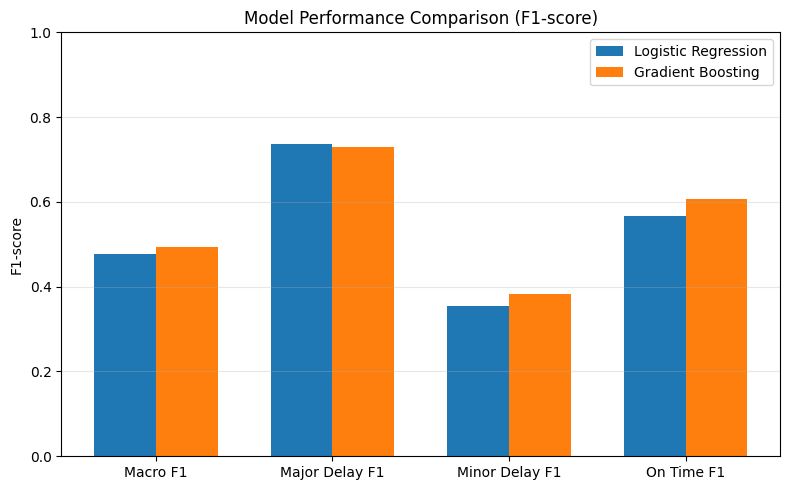

In [111]:
x = np.arange(len(metrics["Metric"]))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    x - width/2,
    metrics["Logistic Regression"],
    width,
    label="Logistic Regression"
)

ax.bar(
    x + width/2,
    metrics["Gradient Boosting"],
    width,
    label="Gradient Boosting"
)

ax.set_ylabel("F1-score")
ax.set_title("Model Performance Comparison (F1-score)")
ax.set_xticks(x)
ax.set_xticklabels(metrics["Metric"], rotation=0)
ax.set_ylim(0, 1)

ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


In [112]:
sample_size = 5000
sample_idx = np.random.choice(len(y_true_hours), size=sample_size, replace=False)

actual = y_true_hours[sample_idx]
predicted = y_pred_hours[sample_idx]

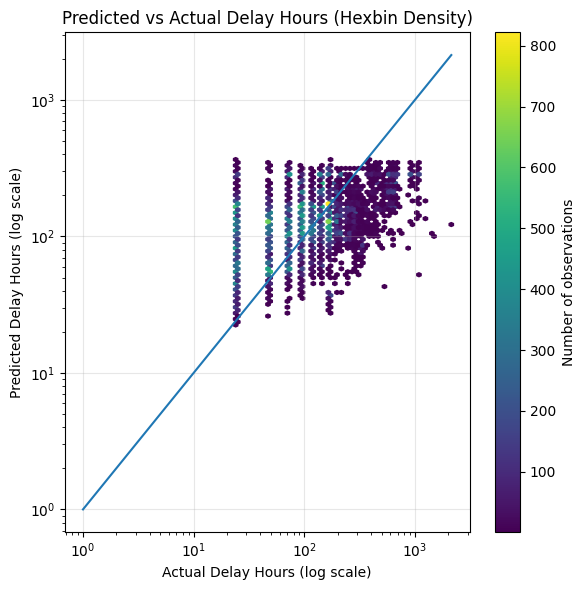

In [113]:
plt.figure(figsize=(6, 6))

hb = plt.hexbin(
    y_true_hours,
    y_pred_hours,
    gridsize=50,
    xscale="log",
    yscale="log",
    mincnt=1
)

# Reference line y = x
max_val = max(y_true_hours.max(), y_pred_hours.max())
plt.plot([1, max_val], [1, max_val])

plt.xlabel("Actual Delay Hours (log scale)")
plt.ylabel("Predicted Delay Hours (log scale)")
plt.title("Predicted vs Actual Delay Hours (Hexbin Density)")

cb = plt.colorbar(hb)
cb.set_label("Number of observations")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [115]:
abs_error = np.abs(y_true_hours - y_pred_hours)

print("MAE check:", abs_error.mean())
print("p50 / p75 / p90 / p95:",
      np.percentile(abs_error, [50, 75, 90, 95]))

MAE check: 85.17809844162753
p50 / p75 / p90 / p95: [ 55.7101417  102.642093   168.79810567 305.56587628]


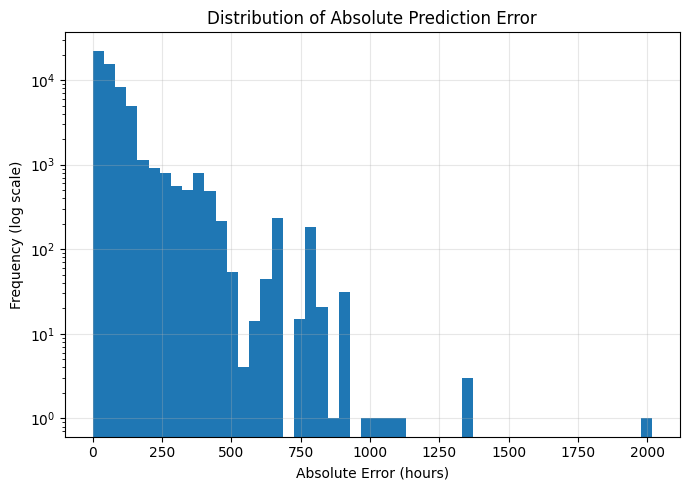

In [116]:
plt.figure(figsize=(7, 5))

plt.hist(
    abs_error,
    bins=50,
    log=True
)

plt.xlabel("Absolute Error (hours)")
plt.ylabel("Frequency (log scale)")
plt.title("Distribution of Absolute Prediction Error")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
